## Simple Imputer for Numerical Data
Simple Imputer is a practical solution for filling missing numerical values in a dataset. This method replaces missing entries with the mean, median, or a specified constant, providing a straightforward approach to address and mitigate the impact of missing numerical data in your dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [3]:
url = "https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day36-imputing-numerical-data/titanic_toy.csv"

In [4]:
df = pd.read_csv(url)

df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [6]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [7]:
X =df.drop(columns=['Survived'])
y = df['Survived']

In [8]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=7)

In [9]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [10]:
X_train.isnull().mean()

Age       0.199438
Fare      0.047753
Family    0.000000
dtype: float64

In [11]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [12]:
X_train["Age_median"] = X_train["Age"].fillna(median_age)
X_train["Age_mean"] = X_train["Age"].fillna(mean_age)

X_train["Fare_median"] = X_train["Fare"].fillna(median_fare)
X_train["Fare_mean"] = X_train["Fare"].fillna(mean_fare)

In [13]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
560,NaN,7.7500,0,28.0,29.334649,7.7500,7.7500
596,NaN,33.0000,0,28.0,29.334649,33.0000,33.0000
124,54.0,77.2875,1,54.0,54.000000,77.2875,77.2875
689,15.0,211.3375,1,15.0,15.000000,211.3375,211.3375
865,42.0,13.0000,0,42.0,42.000000,13.0000,13.0000


In [14]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_median'].var())
print('Age Variance after mean imputation: ', X_train['Age_mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_mean'].var())

Original Age variable variance:  206.7575461859834
Age Variance after median imputation:  165.74900173181422
Age Variance after mean imputation:  165.4641965960963
Original Fare variable variance:  2847.7374433536925
Fare Variance after median imputation:  2727.6035032446575
Fare Variance after mean imputation:  2711.558718917651


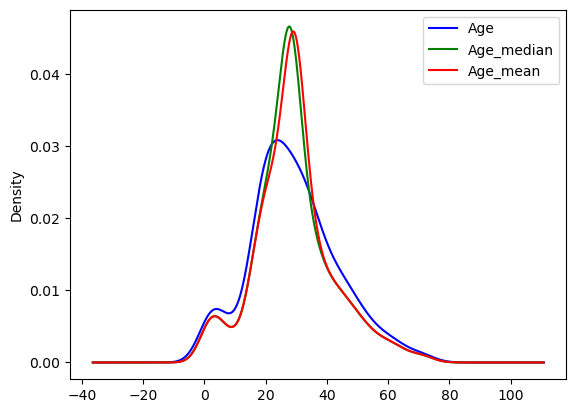

In [15]:
fig = plt.figure()
ax =fig.add_subplot(1,1,1)

#original variable distribution
X_train["Age"].plot(kind = 'kde',ax = ax, color= "blue")
# variable imputed with the median
X_train["Age_median"].plot(kind = 'kde',ax = ax, color= "green")
# variable imputed with the mean
X_train["Age_mean"].plot(kind = 'kde',ax = ax, color= "red")

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'best')

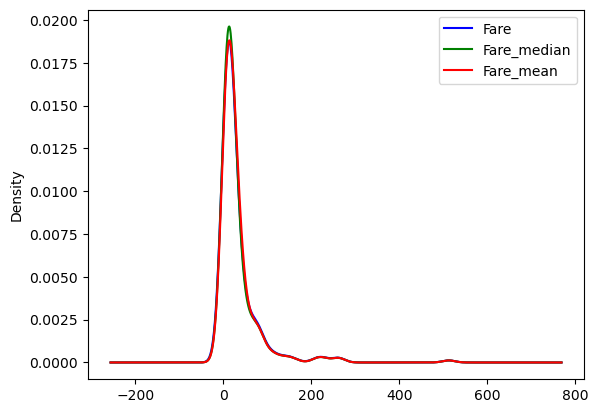

In [16]:
fig = plt.figure()
ax =fig.add_subplot(1,1,1)

#original variable distribution
X_train["Fare"].plot(kind = 'kde',ax = ax, color= "blue")
# variable imputed with the median
X_train["Fare_median"].plot(kind = 'kde',ax = ax, color= "green")
# variable imputed with the mean
X_train["Fare_mean"].plot(kind = 'kde',ax = ax, color= "red")

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'best')

In [17]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,206.757546,84.822002,-6.085785,206.757546,206.757546,78.604333,80.392686
Fare,84.822002,2847.737443,18.253867,70.431104,67.567856,2847.737443,2847.737443
Family,-6.085785,18.253867,2.503864,-4.809828,-4.870340,17.405885,17.380967
Age_median,206.757546,70.431104,-4.809828,165.749002,165.464197,65.604390,67.063091
Age_mean,206.757546,67.567856,-4.870340,165.464197,165.464197,62.905578,64.336763
Fare_median,78.604333,2847.737443,17.405885,65.604390,62.905578,2727.603503,2711.558719
Fare_mean,80.392686,2847.737443,17.380967,67.063091,64.336763,2711.558719,2711.558719


<Axes: >

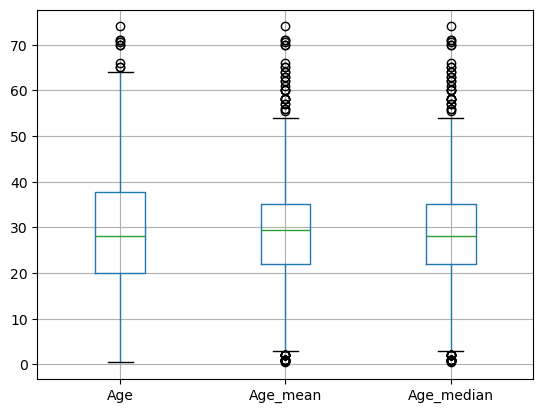

In [18]:
X_train[['Age','Age_mean','Age_median']].boxplot()

<Axes: >

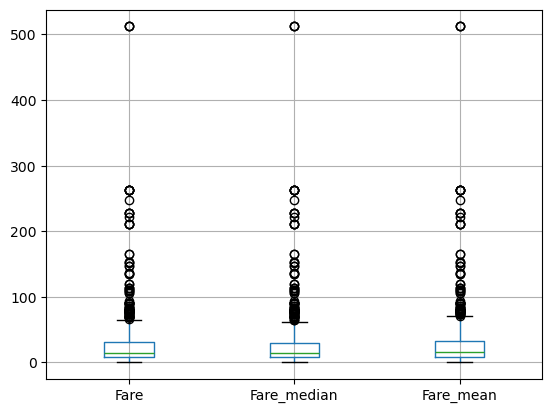

In [19]:
X_train[['Fare','Fare_median','Fare_mean']].boxplot()

Using Sklearn

In [20]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=7)

In [21]:
impute1 = SimpleImputer(strategy='median')
impute2 = SimpleImputer(strategy="mean")

In [22]:
trf = ColumnTransformer(
    transformers=[
        ('impute1', impute1,['Age']),
        ('impute2', impute2,['Fare'])
    ], remainder='passthrough'
)

In [23]:
trf.fit(X_train)

,transformers,"[('impute1', ...), ('impute2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [24]:
trf.named_transformers_['impute1'].statistics_

array([28.])

In [25]:
trf.named_transformers_['impute2'].statistics_

array([33.22930103])

In [26]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)